# Exercise 1: Discretization and Finite Differences

## Learning Objectives

By completing this exercise, you will:
- Understand how to discretize a continuous function on a numerical grid
- Implement forward difference approximations for derivatives
- Analyze the orders of accuracy of numerical schemes
- Investigate the effects of floating-point precision on numerical accuracy

import numpy as np  
import matplotlib.pyplot as plt
import math 
import torch
import importlib

from math import exp, cos 

import nm_lib.nm_ex.nm_lib_ex_1 as nm1
importlib.reload(nm1)

import sys
print(sys.executable)

import nm_lib
print(nm_lib.__file__)

---

## Part 1: Discretization and Numerical Differentiation

### The Test Function

Consider the function

$$h(x) = \cos\left[\frac{\pi (x-1)}{2}\right] \exp\left[-\left(\frac{x-3}{2.5}\right)^2\right],\tag{1}$$

with $x \in (-4,10)$.

### Setting Up the Grid

Let us define a sampling of $h$ with 64 intervals (65 points), storing values into double precision arrays `xx` and `hh`. NumPy arrays use double precision (`float64`) by default.

**Example code to define `xx`:**
```python
import numpy as np

nump = 65
x0 = -4.0 
xf = 10.0
xx = np.arange(nump) / (nump - 1.0) * (xf - x0) + x0
```

Use `matplotlib.pyplot` to visualize `hh` vs `xx`.

### Implementing the Forward Difference

Define `nint` as the number of intervals (`nint = 64`) and `nump` as the number of points. In Python, array indices go from `0` to `nump-1`.

Implement the forward difference formula from the [wiki](https://github.com/AST-Course/AST5110/wiki/Discretization) by completing the function `deriv_fwd` in [`nm_lib`](https://github.com/AST-Course/nm_lib/tree/master/nm_lib/nm_ex/nm_lib_ex_1.py).

> **Note:** Depending on your implementation, you may have `nump` or `nump-1` elements. If the former, the last component (`nump-1`) is ill-calculated. The array `hp` contains a second-order approximation to the derivative at the intermediate points $x_{i+1/2}$.

---

## Exercise

### Task 1.1: Visualize the Discretized Function

Plot `hh` versus `xx` as a solid line with crosses at each grid point (to visualize the quality of the discretization), or use `plt.step` combined with `plt.plot`.

> **Hint:** Make sure the axis pixels are properly located either at the center or half-grid shifted.

### Task 1.2: Compare Numerical and Analytical Derivatives

Plot the numerical derivative array `hp`. Calculate the analytical derivative of function (1) and plot it in the same figure to assess the quality of the approximation.

> **Hint:** Make sure the axis pixels are properly located either at the center or half-grid shifted.

r:\anacodea\envs\ast5110\python.exe
C:\Users\wangu\nm_lib\nm_lib\__init__.py


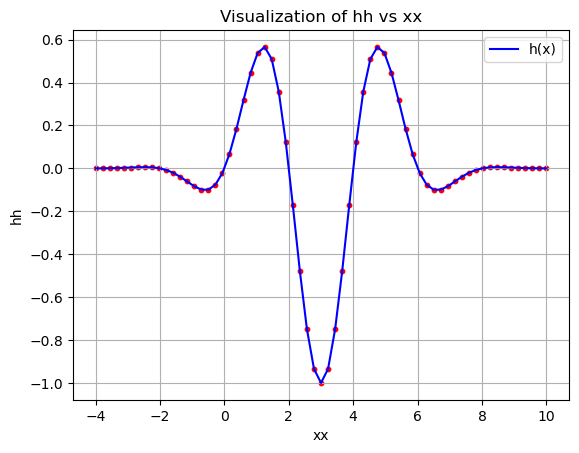

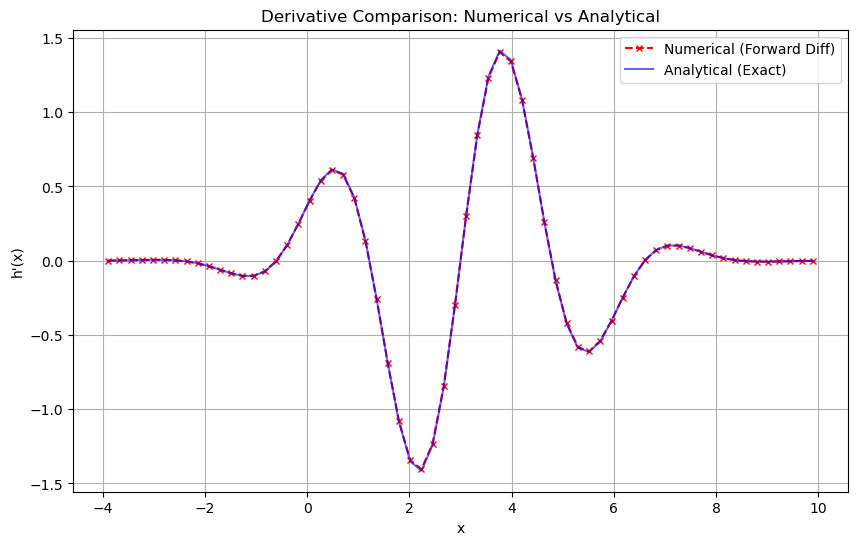

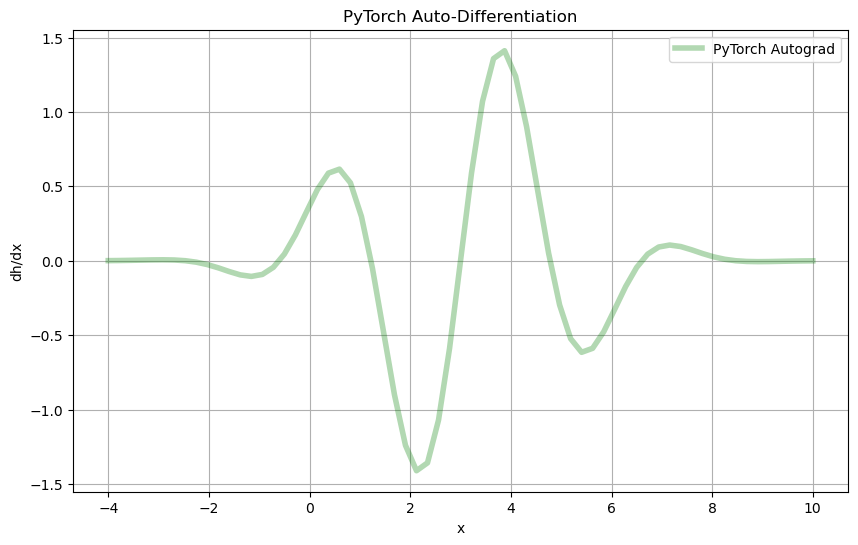

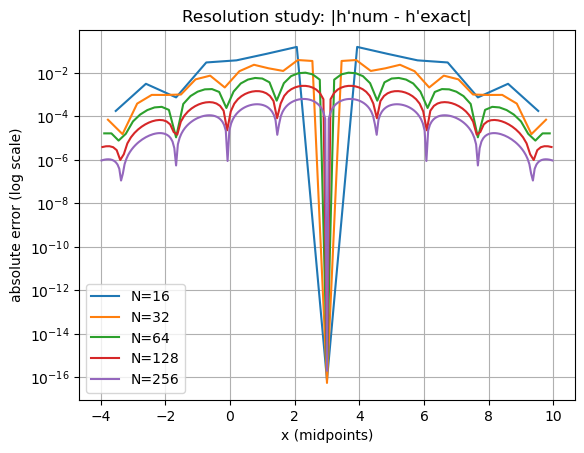

In [21]:
import numpy as np  
import matplotlib.pyplot as plt
import math 
import torch
import importlib

from math import exp, cos 

import nm_lib.nm_ex.nm_lib_ex_1 as nm1
importlib.reload(nm1)

import sys
print(sys.executable)

import nm_lib
print(nm_lib.__file__)

# Task 1.1


# Consider the gird 

nump = 65
x0 = -4.0 
xf = 10.0
xx = np.arange(nump) / (nump - 1.0) * (xf - x0) + x0


def h(x):
    return np.cos(np.pi * (x - 1) / 2) * np.exp(-((x - 3) / 2.5)**2)

#compute hh

hh = h(xx)

# Visualize hh vs xx 

plt.figure()
plt.plot(xx, hh, label='h(x)', color='blue')
plt.scatter(xx, hh, s=10, color='red') 
plt.title('Visualization of hh vs xx')
plt.xlabel('xx')
plt.ylabel('hh')
plt.grid(True)
plt.legend()
plt.show()



# Task 1.2


# Consider the grid
nump = 65
x0 = -4.0
xf = 10.0
xx = np.linspace(x0, xf, nump)
dx = xx[1] - xx[0]

# Define the function
def h(x):
    return np.cos(np.pi * (x - 1) / 2) * np.exp(-((x - 3) / 2.5)**2)

# Compute h
hh = h(xx)

# Numerical derivation (forward diff)
# Here I use the lib function
hp_numeric = nm1.deriv_fwd(xx, hh)[:-1]
xx_mid = 0.5 * (xx[1:] + xx[:-1])

# Analytical derivation (chain rule + product rule)
def h_analytical(x):
    # u = pi*(x-1)/2
    # v = -((x-3)/2.5)^2
    # h = cos(u) * exp(v)

    u = np.pi * (x - 1) / 2
    v = -((x - 3) / 2.5)**2

    u_prime = np.pi / 2
    v_prime = -(2 * (x - 3)) / (2.5**2)

    return (-np.sin(u) * u_prime) * np.exp(v) + np.cos(u) * (np.exp(v) * v_prime)

hp_analytical = h_analytical(xx_mid)

# Plot: numerical vs analytical
plt.figure(figsize=(10, 6))
plt.plot(xx_mid, hp_numeric, 'r--', label='Numerical (Forward Diff)', marker='x', markersize=4)
plt.plot(xx_mid, hp_analytical, 'b-', label='Analytical (Exact)', alpha=0.6)
plt.title('Derivative Comparison: Numerical vs Analytical')
plt.xlabel('x')
plt.ylabel("h'(x)")
plt.legend()
plt.grid(True)
plt.show()

# PyTorch autograd
x_torch = torch.linspace(x0, xf, nump, dtype=torch.float64, requires_grad=True)

def h_torch_func(x):
    term1 = torch.pi * (x - 1) / 2
    term2 = (x - 3) / 2.5
    return torch.cos(term1) * torch.exp(-(term2**2))

y = h_torch_func(x_torch)
y.sum().backward()   # just make it scalar then backward

grad_torch = x_torch.grad.detach().numpy()
x_numpy = x_torch.detach().numpy()

plt.figure(figsize=(10, 6))
plt.plot(x_numpy, grad_torch, 'g-', linewidth=4, alpha=0.3, label='PyTorch Autograd')
plt.title("PyTorch Auto-Differentiation")
plt.xlabel("x")
plt.ylabel("dh/dx")
plt.legend()
plt.grid(True)
plt.show()



# Task 1.3


#Setting the nint list with 16, 32, 64, 128, 256
nint_list = [16, 32, 64, 128, 256]
x0, xf = -4.0, 10.0


#Define the function 
def h(x):
    return np.cos(np.pi * (x - 1) / 2) * np.exp(-((x - 3) / 2.5)**2)


#Find the derivative 
def h_prime(x):
    u = np.pi * (x - 1) / 2
    v = -((x - 3) / 2.5)**2
    u_prime = np.pi / 2
    v_prime = -(2 * (x - 3)) / (2.5**2)
    return (-np.sin(u) * u_prime) * np.exp(v) + np.cos(u) * (np.exp(v) * v_prime)

plt.figure()
for N in nint_list:
    xx = np.linspace(x0, xf, N)   
    hh = h(xx)

    hp_num = nm1.deriv_fwd(xx, hh)[:-1]
    xx_mid = 0.5 * (xx[1:] + xx[:-1])
    err = np.abs(hp_num - h_prime(xx_mid))

    plt.semilogy(xx_mid, err, label=f"N={N}")

plt.title("Resolution study: |h'num - h'exact|")
plt.xlabel("x (midpoints)")
plt.ylabel("absolute error (log scale)")
plt.grid(True)
plt.legend()
plt.show()


# JMS 

<span style="color:green">Good job!</span> 

---

## Part 2: Testing the Order of Accuracy

### Task 2.1: Accuracy Analysis

Test whether the ratio $(h_{i+1}-h_i)/(x_{i+1}-x_i)$ approaches the analytical derivative value.

**Steps:**
1. Use samplings with 16, 32, 64, 128, 256, 512, 1024 intervals (successive powers of 2), plus $10^5$, $10^6$, and $2 \times 10^6$
2. Calculate the **maximum absolute error** between analytical and numerical derivatives at the same points
3. Plot error vs. interval size using **logarithmic axes**
4. Verify if the curve shows a **quadratic dependence**

### Task 2.2: Fit the Convergence Rate

Fit a straight line to the logarithm of the error curve using `numpy.polyfit` and `numpy.poly1d`. From the slope, determine how accurately you obtain the expected quadratic dependence.

> **Note:** Only fit in the region that is linear in the log-log plot.

### Task 2.3: Machine Precision Effects

**Questions to explore:**
1. What happens with $10^6$ grid points?
2. What happens with different floating-point precisions?

Test with:
- `np.float32` (single precision)
- `np.float64` (double precision — NumPy default)
- `np.float128` (extended precision)

> **Warning:** `np.float128` sometimes causes errors with `np.roll`!

Explain the error slopes you observe. What is happening with `np.float128`?

Fitted slope = 1.9909112719266835


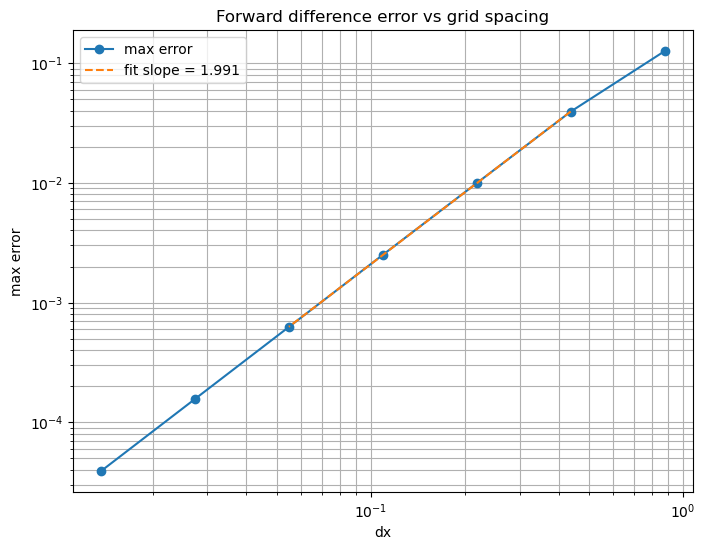

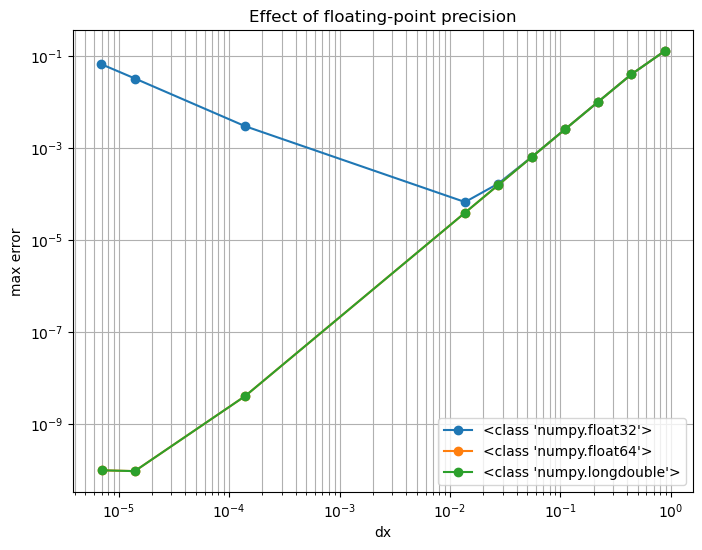

In [22]:
#Part 2

nint_list = [16, 32, 64, 128, 256, 512, 1024]
dx_list = []
err_list = []

for nint in nint_list:
    xx = np.linspace(x0, xf, nint + 1, dtype=np.float64)
    hh = h(xx)

    hp_num = nm1.deriv_fwd(xx, hh)[:-1]
    xx_mid = 0.5 * (xx[1:] + xx[:-1])

    err = np.max(np.abs(hp_num - h_prime(xx_mid)))

    dx_list.append(xx[1] - xx[0])
    err_list.append(err)

dx_arr = np.array(dx_list)
err_arr = np.array(err_list)

# fit in log-log space
fit_slice = slice(1, 5)
coef = np.polyfit(np.log(dx_arr[fit_slice]), np.log(err_arr[fit_slice]), 1)
poly = np.poly1d(coef)

print("Fitted slope =", coef[0])

plt.figure(figsize=(8,6))
plt.loglog(dx_arr, err_arr, 'o-', label='max error')

fit_dx = dx_arr[fit_slice]
plt.loglog(fit_dx, np.exp(poly(np.log(fit_dx))), '--', label=f'fit slope = {coef[0]:.3f}')

plt.xlabel('dx')
plt.ylabel('max error')
plt.title('Forward difference error vs grid spacing')
plt.grid(True, which='both')
plt.legend()
plt.show()

def h_dtype(x, dtype):
    one = dtype(1.0)
    two = dtype(2.0)
    three = dtype(3.0)
    twofive = dtype(2.5)
    pi = dtype(np.pi)

    return np.cos(pi * (x - one) / two) * np.exp(-((x - three) / twofive)**2)


def h_prime_dtype(x, dtype):
    one = dtype(1.0)
    two = dtype(2.0)
    three = dtype(3.0)
    twofive = dtype(2.5)
    pi = dtype(np.pi)

    u = pi * (x - one) / two
    v = -((x - three) / twofive)**2

    u_prime = pi / two
    v_prime = -(two * (x - three)) / (twofive**2)

    return (-np.sin(u) * u_prime) * np.exp(v) + np.cos(u) * np.exp(v) * v_prime

dtype_list = [np.float32, np.float64]
if hasattr(np, "float128"):
    dtype_list.append(np.float128)
else:
    dtype_list.append(np.longdouble)

nint_list_prec = [16, 32, 64, 128, 256, 512, 1024, 100_000, 1_000_000, 2_000_000]

plt.figure(figsize=(8,6))

for dtype in dtype_list:
    dxs = []
    errs = []

    for nint in nint_list_prec:
        xx = np.linspace(dtype(x0), dtype(xf), nint + 1, dtype=dtype)
        hh = h_dtype(xx, dtype)

        hp_num = (hh[1:] - hh[:-1]) / (xx[1:] - xx[:-1])
        xx_mid = 0.5 * (xx[1:] + xx[:-1])

        err = np.max(np.abs(hp_num - h_prime_dtype(xx_mid, dtype)))
        dxs.append(float(xx[1] - xx[0]))
        errs.append(float(err))

    plt.loglog(dxs, errs, 'o-', label=str(dtype))

plt.xlabel('dx')
plt.ylabel('max error')
plt.title('Effect of floating-point precision')
plt.grid(True, which='both')
plt.legend()
plt.show()

# JMS 

<span style="color:green"> Looks good and I see comments are below.</span> 

<span style="color:orange">Note that the last point dx~10^0 it moves away from the slope, could you say why?</span>

In [ ]:
# The last point corresponds to the coarsest grid.
# It deviates from the fitted slope because, for large dx,
# the scheme is not yet fully in the asymptotic O(dx^2) regime.
# Higher-order terms still affect the error, so I only fit the linear part of the log-log plot.

---

## Part 3: Analytical Proof of Accuracy Order (Optional)

### Taylor Expansion Analysis

Consider uniform grid spacing $(\Delta x)_i = \Delta x$. Write Taylor expansions:

$$f(x_{i+1}) = f(x_{i+1/2}) + f'(x_{i+1/2})\frac{\Delta x}{2} + ...  \tag{2}$$

$$f(x_{i}) = f(x_{i+1/2}) - f'(x_{i+1/2})\frac{\Delta x}{2} + ...  \tag{3}$$

Include terms up to order $(\Delta x)^3$. By combining these expressions and eliminating terms, prove that the finite-difference approximation to the derivative at midpoints $x_{i+1/2}$ is **2nd order accurate**.

What is the accurate precission for the finite-difference approximation to the derivative at midpoints $x_{i}$?

---

## Part 4: Fourth-Order Formula (Optional)

### Task 4.1: Implement Fourth-Order Scheme

Implement the finite difference formula given by the first term on the right of Eq. (6) in the [wiki](https://github.com/AST-Course/AST5110/wiki/Discretization). Test if you obtain an approximation with error converging like $(\Delta x)^4$.

### Task 4.2: Compare Convergence Rates

Compare the 2nd-order and 4th-order error slopes for grids with 16, 32, 64, 128, 256, ... intervals.

---

## Hints

<details>
<summary><b>Hint 1: Calculating the analytical derivative</b></summary>

For $h(x) = \cos\left[\frac{\pi (x-1)}{2}\right] \exp\left[-\left(\frac{x-3}{2.5}\right)^2\right]$, use the product rule:
$$h'(x) = \frac{d}{dx}[\cos(...)] \cdot \exp(...) + \cos(...) \cdot \frac{d}{dx}[\exp(...)]$$
</details>

<details>
<summary><b>Hint 2: Log-log plot interpretation</b></summary>

In a log-log plot, a power law $\text{error} \propto (\Delta x)^m$ appears as a straight line with slope $m$.
</details>

<details>
<summary><b>Hint 3: Machine precision floor</b></summary>

At very fine resolutions, round-off errors dominate and the error stops decreasing. This happens around $\epsilon_{\text{machine}} / \Delta x$.
</details>

In [24]:
#Task 4


#Consider the intial value

nint_list = [16, 32, 64, 128, 256]
x0, xf = -4.0, 10.0

#Define the function

def h(x):
    return np.cos(np.pi*(x-1)/2) * np.exp(-((x-3)/2.5)**2)

#Define the analitical 
def h_prime(x):
    u = np.pi*(x-1)/2
    v = -((x-3)/2.5)**2
    return (-np.sin(u)*(np.pi/2))*np.exp(v) + np.cos(u)*np.exp(v)*(-(2*(x-3))/(2.5**2))

dx_list = []
E2 = []
E4 = []

for N in nint_list:
    x = np.linspace(x0, xf, N+1)      # N intervals
    dx = x[1] - x[0]
    f = h(x)

    # 2nd order: central difference (use i-1,i+1), valid on i=1..N-1
    d2 = (f[2:] - f[:-2])/(2*dx)
    e2 = np.max(np.abs(d2 - h_prime(x[1:-1])))

    # 4th order: five-point stencil, valid on i=2..N-2
    d4 = (f[:-4] - 8*f[1:-3] + 8*f[3:-1] - f[4:])/(12*dx)
    e4 = np.max(np.abs(d4 - h_prime(x[2:-2])))

    dx_list.append(dx)
    E2.append(e2)
    E4.append(e4)

print("N   dx        maxerr2      order2   maxerr4      order4")
for k in range(len(nint_list)):
    N = nint_list[k]
    if k == 0:
        print(N, dx_list[k], E2[k], "-", E4[k], "-")
    else:
        order2 = np.log2(E2[k-1]/E2[k])   # reduce the dx
        order4 = np.log2(E4[k-1]/E4[k])
        print(N, dx_list[k], E2[k], order2, E4[k], order4)
# The conclusion:

# The numerical derivative also agrees very well with the analytical derivative in the comparison plot.
# The largest errors appear in the regions where the function changes most rapidly.
# From the plot, we see that refining the grid (larger N) reduces the error, as expected.
# Overall, the results show that the numerical approximation becomes more accurate as the resolution increases.

# The log-log plot also shows that the fitted slope is close to 2, which confirms the expected second-order accuracy.
# When we increase the mesh density, the observed convergence order of the error is approximately 2 for the second-order scheme
# and approximately 4 for the fourth-order scheme, which confirms the expected accuracy.

# For very fine grids, the floating-point precision study shows that roundoff errors may become important.

N   dx        maxerr2      order2   maxerr4      order4
16 0.875 0.5164644101062815 - 0.25218660976014795 -
32 0.4375 0.14556675871029312 1.8269879928442625 0.021934208244963838 3.523237139850042
64 0.21875 0.03929584459872282 1.8892322770388885 0.0017095338104256008 3.6815077694333054
128 0.109375 0.009941569011108875 1.9828312947349038 0.00010939930546038923 3.9659274719727122
256 0.0546875 0.0025030530312917243 1.9897847034165397 6.8780261601730786e-06 3.991465165663898


# JMS 

<span style="color:green"> Good job.</span> 

<span style="color:orange">See my minor comment that we can chat in the next meeting unless you know the answer. </span>

<span style="color:green"> Otherwise this looks great including the optional.</span> 


